In [2]:
import numpy as np 
import matplotlib.pyplot as plt 
from astro_peek.identifier.cca import CCA_Score
from astro_peek.nets.encoder_base import Encoder
from astro_peek.trainer.transforms import patch_cifar10
import torch

torch.set_num_threads(1)
torch.set_num_interop_threads(1)

/home/ssalhi/model_training/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
'''Load the two ENCODER_FEATURES models and pass the training set into both of them. This will map the training set x to the latent space'''

models_path = '/home/ssalhi/scratch/crl/experiments/cifar10/models/encoder_features/'

encoder_1_path = models_path + 'seed_38_latentdim_64_epochs_1000_lr_0.0001_batchsize_256.pt'
encoder_2_path = models_path + 'seed_39_latentdim_64_epochs_1000_lr_0.0001_batchsize_256.pt'

print("Loading the models for different random seeds ")
model_data_1 = torch.load(encoder_1_path, map_location="cpu")
model_data_2 = torch.load(encoder_2_path, map_location="cpu")

model_cfg_1 = model_data_1["model_cfg"]
model_cfg_2 = model_data_2["model_cfg"]

encoder_1 = Encoder(model_cfg_1)
encoder_2 = Encoder(model_cfg_2)

encoder_1.load_state_dict(model_data_1["model"])
encoder_2.load_state_dict(model_data_2["model"])


# load the data
x = torch.load("/home/ssalhi/scratch/cifar10_data/features.pt", weights_only=False)
y = torch.load("/home/ssalhi/scratch/cifar10_data/labels.pt",   weights_only=False)
x = torch.as_tensor(x).squeeze().contiguous()
y = torch.as_tensor(y).squeeze().contiguous()
N = x.shape[0]


# flatten the images 
x = x.reshape(N, -1)
y = y.reshape(N, -1)
print(x.shape)

latents_model_1 = encoder_1(x)
latents_model_2 = encoder_2(x)

print(latents_model_1.shape, latents_model_2.shape)

Loading the models for different random seeds 
torch.Size([50000, 768])
torch.Size([50000, 64]) torch.Size([50000, 64])


In [7]:
'''Make sure the latents have the right shape. Concatenate them into one array so that model_list has shape (2, nsamples, nlatents)'''

model_latent_list = torch.stack([latents_model_1, latents_model_2], axis=0)
print(model_latent_list.shape)

torch.Size([2, 50000, 64])


(64,)


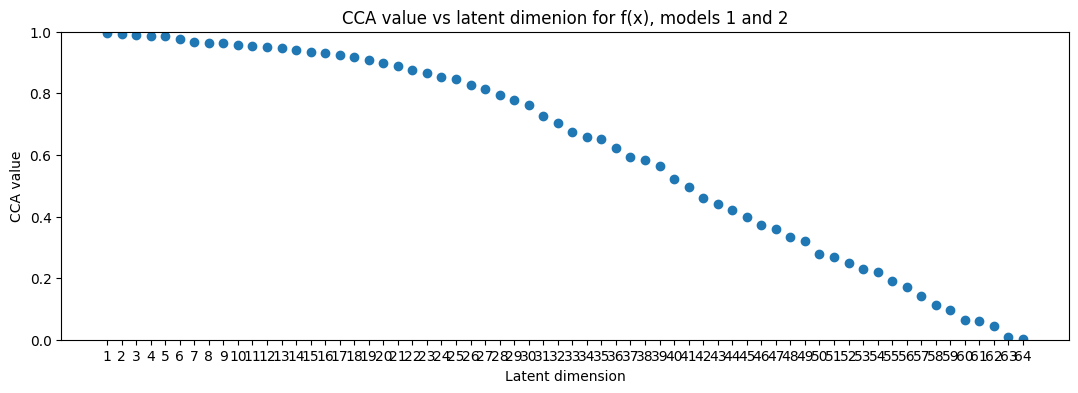

In [8]:
'''Create a CCA_Score object with the model_list, calculate the pairwise CCA values, and plot them.'''

CCA = CCA_Score(model_list=model_latent_list.detach().numpy())
corrs = CCA.compute_one_pair_cca()

print(corrs.shape)

# plot the CCA scores as a function of the latents 
CCA.plot_cca_v_latent(corrs)

## Testing comparison between more than 2 models

In [9]:
from tqdm import tqdm 

def load_model(paths):
    model_list = []
    for path in tqdm(paths): 
        model_data = torch.load(path, map_location = "cpu")
        cfg = model_data['model_cfg']
        model = Encoder(cfg)
        model.load_state_dict(model_data["model"])
        model_list.append(model)
    return model_list

In [ ]:
from glob import glob
from natsort import natsorted

model_path = "/home/ssalhi/scratch/crl/experiments/cifar10/models/"
encoders_features_dir = "encoder_features/"
encoders_labels_dir = "encoder_labels/"
pattern = "*.pt"

encoder_x_paths = natsorted(glob(model_path + encoders_features_dir + pattern))  
encoder_y_paths = natsorted(glob(model_path + encoders_labels_dir + pattern))

print("Loading the models for different random seeds ")
encoder_x_list = load_model(encoder_x_paths)
encoder_y_list = load_model(encoder_y_paths)

In [ ]:
# make the list of models 
model_list_x = []
model_list_y = []
for i in range(len(encoder_x_list)):
    latents_x = encoder_x_list[i](x)
    latents_y = encoder_y_list[i](y)
    
    model_list_x.append(latents_x)
    model_list_y.append(latents_y)
    
model_list_x = torch.stack(model_list_x, axis=0)
model_list_y = torch.stack(model_list_y, axis=0)

print(model_list_x.shape, model_list_y.shape)

In [ ]:
# calculate all pairwise CCA scores
CCA_multi_x = CCA_Score(model_list=model_list_x.detach().numpy())
CCA_multi_y = CCA_Score(model_list=model_list_y.detach().numpy())

mcorrs_x = CCA_multi_x.compute_all_pairwise_cca()
mcorrs_y = CCA_multi_y.compute_all_pairwise_cca()

print(mcorrs_x.shape, mcorrs_y.shape)

In [ ]:
# plot different pairwise comparisons for f(x)
CCA_multi_x.plot_cca_v_latent(mcorrs_x, models=[0,1], encoder_type='f(x)')
CCA_multi_x.plot_cca_v_latent(mcorrs_x, models=[0,2], encoder_type='f(x)')
CCA_multi_x.plot_cca_v_latent(mcorrs_x, models=[0,3], encoder_type='f(x)')
CCA_multi_x.plot_cca_v_latent(mcorrs_x, models=[0,4], encoder_type='f(x)')
CCA_multi_x.plot_cca_v_latent(mcorrs_x, models=[0,5], encoder_type='f(x)')
CCA_multi_x.plot_cca_v_latent(mcorrs_x, models=[0,6], encoder_type='f(x)')
CCA_multi_x.plot_cca_v_latent(mcorrs_x, models=[0,7], encoder_type='f(x)')
CCA_multi_x.plot_cca_v_latent(mcorrs_x, models=[0,8], encoder_type='f(x)')
CCA_multi_x.plot_cca_v_latent(mcorrs_x, models=[0,9], encoder_type='f(x)')
# CCA_multi_x.plot_cca_v_latent(mcorrs_x, models=[1,2], encoder_type='f(x)')
# CCA_multi_x.plot_cca_v_latent(mcorrs_x, models=[3,4], encoder_type='f(x)')

In [ ]:
# plot different pairwise comparisons for g(y)
CCA_multi_y.plot_cca_v_latent(mcorrs_y, models=[0,1], encoder_type='g(y)')
CCA_multi_y.plot_cca_v_latent(mcorrs_y, models=[0,2], encoder_type='g(y)')
CCA_multi_y.plot_cca_v_latent(mcorrs_y, models=[0,3], encoder_type='g(y)')
CCA_multi_y.plot_cca_v_latent(mcorrs_y, models=[0,4], encoder_type='g(y)')
CCA_multi_y.plot_cca_v_latent(mcorrs_y, models=[1,2], encoder_type='g(y)')
CCA_multi_y.plot_cca_v_latent(mcorrs_y, models=[3,4], encoder_type='g(y)')

In [ ]:
# calculate the mean CCA value across all models and plot it against the latents 
mean_cca_x = CCA_multi_x.calculate_mean_cca(mcorrs_x)
mean_cca_y = CCA_multi_y.calculate_mean_cca(mcorrs_y)

print(mean_cca_x.shape, mean_cca_y.shape)

CCA_multi_x.plot_cca_v_latent(mean_cca_x, encoder_type='f(x)', mean=True)
CCA_multi_y.plot_cca_v_latent(mean_cca_y, encoder_type='g(y)', mean=True)

## Compare different epochs

100%|██████████| 2/2 [00:00<00:00, 342.27it/s]


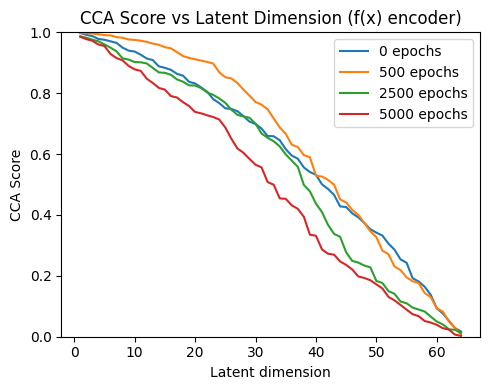

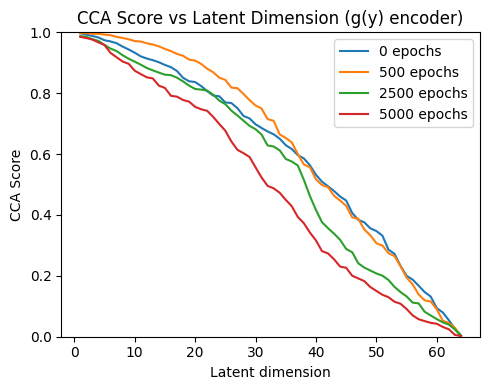

In [22]:
import os

def cca_by_epoch(
    model_path: str,
    epoch_to_filenames: dict[int, list[str]],
    x: torch.Tensor,
    y: torch.Tensor,
    load_model,
    CCA_Score,
    device: str | torch.device = "cpu",
):
    """
    Compute and plot CCA-vs-latent-dim for encoder x and encoder y across epochs.

    Args:
        model_path: Base path ending with .../models/
        epoch_to_filenames: {epoch: [file_for_seed1, file_for_seed2, ...]}
                           Same filenames are expected under encoder_features/ and encoder_labels/.
        x, y: Inputs for encoder_features and encoder_labels respectively.
        load_model: Function that loads a list of model paths -> list of models.
        CCA_Score: CCA class with .compute_one_pair_cca() and .ndims.
        device: device for forward pass.
    Returns:
        results: dict keyed by epoch with CCA arrays for x/y.
    """
    x = x.to(device)
    y = y.to(device)

    def _latent_stack(models, inp):
        outs = []
        for m in models:
            m = m.to(device)
            m.eval()
            with torch.no_grad():
                outs.append(m(inp).detach().cpu())
        return torch.stack(outs, dim=0)  # (n_models, n_samples, latent_dim)

    results = {}

    # Sort epochs for consistent plotting
    for epoch in sorted(epoch_to_filenames.keys()):
        files = epoch_to_filenames[epoch]

        enc_x_paths = [os.path.join(model_path, "encoder_features", f) for f in files]
        enc_y_paths = [os.path.join(model_path, "encoder_labels", f) for f in files]

        models_x = load_model(enc_x_paths)
        models_y = load_model(enc_y_paths)

        latents_x = _latent_stack(models_x, x)
        latents_y = _latent_stack(models_y, y)

        cca_x = CCA_Score(model_list=latents_x.numpy())
        cca_y = CCA_Score(model_list=latents_y.numpy())

        corrs_x = cca_x.compute_one_pair_cca()
        corrs_y = cca_y.compute_one_pair_cca()

        results[epoch] = {
            "corrs_x": corrs_x,
            "corrs_y": corrs_y,
            "ndims_x": cca_x.ndims,
            "ndims_y": cca_y.ndims,
        }

    # Plot X encoders
    plt.figure(figsize=(5, 4))
    for epoch in sorted(results.keys()):
        nd = results[epoch]["ndims_x"]
        dims = np.arange(1, nd + 1)
        plt.plot(dims, results[epoch]["corrs_x"], label=f"{epoch} epochs")
    plt.xlabel("Latent dimension")
    plt.ylabel("CCA Score")
    plt.title("CCA Score vs Latent Dimension (f(x) encoder)")
    plt.ylim(0, 1)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Plot Y encoders
    plt.figure(figsize=(5, 4))
    for epoch in sorted(results.keys()):
        nd = results[epoch]["ndims_y"]
        dims = np.arange(1, nd + 1)
        plt.plot(dims, results[epoch]["corrs_y"], label=f"{epoch} epochs")
    plt.xlabel("Latent dimension")
    plt.ylabel("CCA Score")
    plt.title("CCA Score vs Latent Dimension (g(y) encoder)")
    plt.ylim(0, 1)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return results

epoch_to_files = {
    0: [
        "seed_38_latentdim_64_epochs_0_lr_0.0001.pt",
        "seed_39_latentdim_64_epochs_0_lr_0.0001.pt",
    ],
    500: [
        "seed_38_latentdim_64_epochs_500_lr_0.0001_batchsize_256.pt",
        "seed_39_latentdim_64_epochs_500_lr_0.0001_batchsize_256.pt",
    ],
    2500: [
        "seed_38_latentdim_64_epochs_2500_lr_0.0001_batchsize_256.pt",
        "seed_39_latentdim_64_epochs_2500_lr_0.0001_batchsize_256.pt",
    ],
    5000: [
        "seed_38_latentdim_64_epochs_5000_lr_0.0001_batchsize_256.pt",
        "seed_39_latentdim_64_epochs_5000_lr_0.0001_batchsize_256.pt",
    ],
}

results = cca_by_epoch(
    model_path="/home/ssalhi/scratch/crl/experiments/cifar10/models/",
    epoch_to_filenames=epoch_to_files,
    x=x,
    y=y,
    load_model=load_model,
    CCA_Score=CCA_Score,
    device="cpu",
)

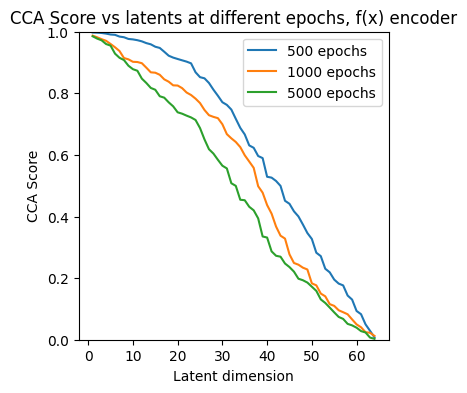

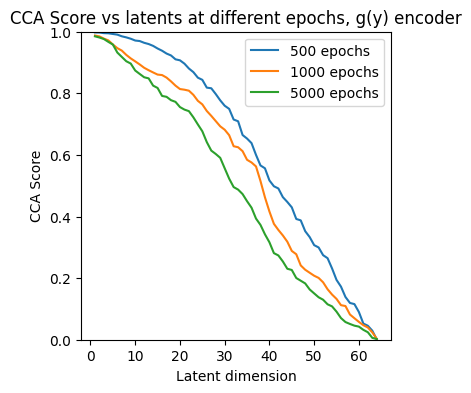

In [20]:
# plot each mean for each encoder type (two plots, one for f(x) and one for g(y))
dims_x = np.arange(1, CCA_5k_x.ndims+1)
# print(CCA_5k_x_copy)

plt.figure(figsize=(4,4))
# plt.plot(dims_x, corrs_0_x, "-", label="0 epochs")
plt.plot(dims_x, corrs_400_x, "-", label="500 epochs")
plt.plot(dims_x, corrs_1k_x, "-", label="1000 epochs")
plt.plot(dims_x, corrs_5k_x, "-", label="5000 epochs")
# plt.plot(dims_x, CCA_0_x_copy, "-", label="0 epochs")
# plt.plot(dims_x, CCA_1k_x_copy, "-", label="1000 epochs")
# plt.plot(dims_x, CCA_5k_x_copy, "-", label="5000 epochs")
plt.xlabel("Latent dimension")
plt.ylabel('CCA Score')
plt.title('CCA Score vs latents at different epochs, f(x) encoder')
plt.xticks(np.arange(0, CCA_5k_x.ndims, 10))
plt.ylim(0,1)
plt.legend()
plt.show()

dims_y = np.arange(1, CCA_5k_y.ndims+1)
plt.figure(figsize=(4,4))
# plt.plot(dims_y, corrs_0_y, "-", label="0 epochs")
plt.plot(dims_y, corrs_400_y, "-", label="500 epochs")
plt.plot(dims_y, corrs_1k_y, "-", label="1000 epochs")
plt.plot(dims_y, corrs_5k_y, "-", label="5000 epochs")
plt.xlabel("Latent dimension")
plt.ylabel('CCA Score')
plt.title('CCA Score vs latents at different epochs, g(y) encoder')
plt.xticks(np.arange(0, CCA_5k_y.ndims, 10))
plt.ylim(0,1)
plt.legend()
plt.show()


### Visualize the latents 

In [ ]:
# fig, axs = plt.subplots(len(encoder_x_list), 2, figsize = (12, 4 * len(encoder_x_list)))

# for i, row_axs in enumerate(axs):
#     encoder_x = encoder_x_list[i]
#     encoder_y = encoder_y_list[i]
#     with torch.no_grad():
#         zx = encoder_x(torch.tensor(x).to(torch.float32))
#         zy = encoder_y(torch.tensor(y).to(torch.float32))
#     ax = row_axs[0]
    
#     ax.scatter(*zx.cpu().T)
#     ax.set(title = "Encoding features", xlabel = r"$\vec{f}(\mathbf{x})$ 1st dim", ylabel = r"$\vec{f}(\mathbf{x})$ 2nd dim")
#     ax = row_axs[1]
#     ax.scatter(*zy.cpu().T, vmin  = 0, vmax = 1, cmap = "bwr")
#     ax.set(title = "Encoding labels", xlabel = r"$\vec{g}(\mathbf{y})$ 1st dim", ylabel = r"$\vec{g}(\mathbf{y})$ 2nd dim")


# plt.subplots_adjust(wspace = 0.5, hspace = 0.5)